#### Autoregressive Models

##### **Autoregressive Models of Order p, AR(p)**

The autoregressive model with $p$ lags, abbreviated as the AR(p) model, is a common model for time series data used in various applications.
The model takes the form $Y(t) = \sum_{i=1}^{p} a_i Y(t-i) + W(t)$,
where
- $Y(t)$ represents the value of the time series at time $t$.
- $a_i$ are the model parameters.
- $W(t)$ represents the white noise, meaning $W(t)$ are independently (i.i.d.) for each $t$.
- $E[W(t)] = 0$ (the expected value of the white noise is zero).
- $E[W(t) W(t -\tau)] = \sigma^2 \Delta(\tau)$, the autocovariance of the white noise is $\sigma^2$ when $\tau=0$ and $0$ otherwise, where $\Delta(\tau)$ is the Kronecker delta function.

##### **First-Order Autoregressive Process AR(1)**

The AR(1) is a specific case of the AR(p) model where $p=1$, defined by $X_t = \alpha X_{t-1} + W_t$,
where:
- $X_t$ is the value of the time series at time $t$.
- $\alpha$ is the single model parameter.
- $X_{t-1}$ is the previous observation.
- $W_t$ is an i.i.d. random variable following a Gaussian distribution, i.e., $W_t \sim N(0, \sigma^2)$.

This AR(1) process is stationary iff $|\alpha| < 1$. The condition $|\alpha| < 1$ ensures that the influence of past observations diminishes over time, preventing the series from exploding and maintaining a constant mean and variance.

##### **Autocovariance of AR(p)**

An object of interest for the autoregressive model is the autocovariance function (ACF). ACF function is particularly interesting because it quantifies the relationship between two observations of the time series as a function of the time lag between the observations, i.e.,
$R(\tau) = E[Y(t) Y(t -\tau)]$,
where
- $R(\tau)$ is the autocovariance at lag $\tau$.
- $Y(t)$ is the value of the time series at time $t$.
- $Y(t-\tau)$ is the value of the time series at time $t-\tau$ (i.e., $\tau$ periods before $t$).
- $E[\cdot]$ denotes the expected value.

##### **Recursion Relation for Autocovariance (ACF) of AR(p)**

The autocovariance function for an AR(p) process admits the recursion relation and symmetry properties, which are often expressed through the Yule-Walker equations.

For an AR(p) process $Y_t = \sum_{i=1}^{p} a_i Y_{t-i} + W_t$, the autocovariance function $R(\tau) = E[Y_t Y_{t-\tau}]$ satisfies
- $R(\tau) = \sum_{i=1}^{p} a_i R(\tau - i)$ for $\tau > 0$
- $R(0) = \sum_{i=1}^{p} a_i R(-i) + \sigma^2$ for $\tau = 0$

Due to the symmetry of the autocovariance function, $R(\tau) = R(-\tau)$. Therefore, the equation for $\tau=0$ can also be written as
- $R(0) = \sum_{i=1}^{p} a_i R(i) + \sigma^2$

These equations are fundamental for estimating the parameters of an AR(p) model and for understanding the structure of the time series.

##### **Autoregressive Model of Order 2 AR(2)**

Consider AR(2) given by $Y(t) = a_1 Y(t-1) + a_2 Y(t-2) + W(t)$,
where:
- $Y(t)$ is the value of the time series at time $t$.
- $a_1$ and $a_2$ are the model parameters.
- $Y(t-1)$ and $Y(t-2)$ are the previous observations.
- $W(t)$ is an i.i.d. random variable following a Gaussian distribution, i.e., $W(t) \sim N(0, \sigma^2)$.

##### **Yule-Walker Equations for AR(3)**

Consider the stable AR(3) process given by
$x(t) = -\frac{3}{2} x(t -1) - \frac{3}{4} x(t -2) + \frac{1}{8} x(t -3) + \epsilon(t)$,
where:
- $x(t)$ is the value of the time series at time $t$.
- $\epsilon(t)$ is independent white noise with $\epsilon(t) \sim N(0,1)$.

##### **Autocovariance Function (ACF) of AR(p)**
The autocovariance function of AR(p) satisfies the recursion
$R(\tau) = \sum_{k=1}^{p} a_k R(\tau - k) + \sigma^2 \Delta(\tau)$.
Can we find a closed form, general solution, for the ACF using q-transforms?

##### **q-transform**
We defined the q-transform in the context of the convolution kernel $h(t)$, of an LTI system.
Given a time series $Y(t)$, $t \in \mathbb{Z}$ and $q$ with $|q^{-1}| < 1$, its q-transform, denoted as $Q[Y(t)] = \bar{Y}(q)$ is
$Q[Y(t)] = \bar{Y}(q) = \sum_{k=-\infty}^{\infty} Y(k) q^{-k} \in \mathbb{C}$.
This definition implies that the q-transform of the time series $Y(t - \tau)$ with a time shift $\tau$ is
- $Q[Y(t -\tau)] = \sum_{k=-\infty}^{\infty} Y (k-\tau) q^{-k} = q^{-\tau} \sum_{k=-\infty}^{\infty} Y (k -\tau) q^{-(k -\tau)} = q^{-\tau} \bar{Y}(q)$.

**q-transform Practice 1**: Q-transform of the Discrete Delta Function

Compute the q-transform $Q[\Delta(t)]$ of the (discrete) delta function, defined as
$\Delta(t) = \begin{cases} 1 & \text{for } t = 0 \\ 0 & \text{for } t \neq 0 \end{cases}$


In [ ]:
from sympy import symbols, Sum

# Define the variable q and t (for the sum index k)
q, k = symbols('q k')

# Define the delta function (symbolically for the sum)
def delta_function(t_val):
    return 1 if t_val == 0 else 0

# The q-transform definition:
# Q[Y(t)] = Sum(Y(k) * q**(-k), (k, -oo, oo))

# For Delta(t), Y(k) = delta_function(k)
# The sum will only have one non-zero term when k=0
# So, Delta(0) * q**(-0) = 1 * q**0 = 1

# Symbolically representing the sum for explanation:
# Q[Delta(t)] = Sum(delta_function(k) * q**(-k), (k, -oo, oo))
#             = delta_function(...,-2) * q**2 + delta_function(...,-1) * q**1 + delta_function(0) * q**0 + delta_function(1) * q**(-1) + ...
#             = 0 + 0 + 1 * 1 + 0 + 0 = 1

The discrete delta function is defined as:
Delta(t) = 1 for t = 0
Delta(t) = 0 for t != 0

By the definition of the q-transform: Q[Y(t)] = Sum(Y(k) * q**(-k), (k, -oo, oo))
For Delta(t), Y(k) is 1 only when k=0 and 0 otherwise.
Therefore, the sum simplifies to:
Q[Delta(t)] = Delta(0) * q**(-0) = 1 * 1 = 1

Result: Q[Delta(t)] = 1


In [ ]:
from sympy import symbols, Sum, oo

# Define symbolic variables
q, a, k = symbols('q a k')

# Define the geometric sequence X(t) = a^t for t >= 0
# For the q-transform, we sum from k=0 to infinity since X(k) = 0 for k < 0
# X(k) = a**k

# The q-transform definition: Q[Y(t)] = Sum(Y(k) * q**(-k), (k, -oo, oo))
# For X(t), it becomes: Q[X(t)] = Sum(a**k * q**(-k), (k, 0, oo))

# This is a geometric series sum: Sum((a * q**(-1))**k, (k, 0, oo))
# It converges to 1 / (1 - a * q**(-1)) if |a * q**(-1)| < 1
# Given |a| < 1 and |q**(-1)| < 1, this condition holds.

# Calculate the sum symbolically
q_transform_X = 1 / (1 - a * q**(-1))

# Optionally, rewrite in a more simplified form by multiplying numerator and denominator by q
simplified_q_transform_X = (q_transform_X * q) / q

Given X(t) = a^t for t >= 0, and |a| < 1, |q^-1| < 1
The q-transform Q[X(t)] is defined as: Sum(X(k) * q**(-k), (k, -oo, oo))
Since X(k) = 0 for k < 0, the sum simplifies to: Sum(a**k * q**(-k), (k, 0, oo))
This is a geometric series: Sum((a * q**(-1))**k, (k, 0, oo))
For |a * q**(-1)| < 1, the sum converges to: 1 / (1 - a * q**(-1))

Q[X(t)] = 1/(-a/q + 1)
Which can be rewritten as: 1/(-a/q + 1)


##### **Inverse q-transform Practice**

Given the q-transform of a series, $\bar{X}(q) = \frac{1}{1 - 0.8 q^{-1}}$, where $|0.8| < 1$ and $|q^{-1}| < 1$.
Expand this q-transform as a series of the form $\bar{X}(q) = \sum_{t=-\infty}^{\infty} X(t) q^{-t}$.
Recognize that the given form is that of an infinite geometric series $\frac{1}{1-r} = \sum_{k=0}^{\infty} r^k$ for $|r| < 1$, we can set $r = 0.8 q^{-1}$.
Therefore, we can expand $\bar{X}(q)$ as $\bar{X}(q) = \sum_{k=0}^{\infty} (0.8 q^{-1})^k$, $\bar{X}(q) = \sum_{k=0}^{\infty} (0.8)^k (q^{-1})^k$
- $\bar{X}(q) = \sum_{k=0}^{\infty} (0.8)^k q^{-k}$

Comparing this to the definition $\bar{X}(q) = \sum_{t=-\infty}^{\infty} X(t) q^{-t}$, we can identify the coefficients $X(t)$
- $X(t) = \begin{cases} (0.8)^t & \text{for } t \ge 0 \\ 0 & \text{for } t < 0 \end{cases}$

The inverse q-transform of $\bar{X}(q) = \frac{1}{1 - 0.8 q^{-1}}$ is $X(t) = (0.8)^t$ for $t \ge 0$ and $0$ otherwise.

##### **Properties of q-transform**

Given two time series $X(t)$ and $Y(t)$, let their q-transforms be $\bar{X}(q)$ and $\bar{Y}(q)$ respectively.
Compute the q-transforms for the following expressions:

1.  Scalar Multiple: $c \cdot X(t)$ for some scalar $c \in \mathbb{R}$
2.  Sum: $X(t) + Y(t)$
3.  Convolution: $(X * Y)(t) = \sum_{k=-\infty}^{\infty} X(k) Y(t - k)$
4.  Shift: $X(t - \tau)$

In [ ]:
from sympy import symbols, Sum, Function

# Define symbolic variables and functions
q, c, k, tau = symbols('q c k tau')
X = Function('X')
Y = Function('Y')

# 1. Scalar Multiple: Q[c * X(t)]
# By definition: Sum(c * X(k) * q**(-k), (k, -oo, oo))
# = c * Sum(X(k) * q**(-k), (k, -oo, oo))
# = c * Q[X(t)] = c * X_bar(q)

# 2. Sum: Q[X(t) + Y(t)]
# By definition: Sum((X(k) + Y(k)) * q**(-k), (k, -oo, oo))
# = Sum(X(k) * q**(-k), (k, -oo, oo)) + Sum(Y(k) * q**(-k), (k, -oo, oo))
# = Q[X(t)] + Q[Y(t)] = X_bar(q) + Y_bar(q)

# 3. Convolution: Q[(X * Y)(t)] = Q[Sum(X(k) * Y(t - k))]
# Let Z(t) = (X * Y)(t)
# Q[Z(t)] = Sum(Z(j) * q**(-j), (j, -oo, oo))
#         = Sum(Sum(X(k) * Y(j - k)) * q**(-j), (j, -oo, oo))
# Swapping summation order and rearranging:
#         = Sum(X(k) * Sum(Y(j - k) * q**(-j)), (k, -oo, oo))
# Let m = j - k, so j = m + k
#         = Sum(X(k) * Sum(Y(m) * q**(-(m+k))), (k, -oo, oo))
#         = Sum(X(k) * q**(-k) * Sum(Y(m) * q**(-m)), (k, -oo, oo))
#         = (Sum(X(k) * q**(-k), (k, -oo, oo))) * (Sum(Y(m) * q**(-m), (m, -oo, oo)))
#         = Q[X(t)] * Q[Y(t)] = X_bar(q) * Y_bar(q)

# 4. Shift: Q[X(t - tau)]
# As derived in the introduction: Q[X(t - tau)] = q**(-tau) * Q[X(t)] = q**(-tau) * X_bar(q)

1. Q[c * X(t)] = c * Q[X(t)]
2. Q[X(t) + Y(t)] = Q[X(t)] + Q[Y(t)]
3. Q[ (X * Y)(t) ] = Q[X(t)] * Q[Y(t)]
4. Q[X(t - tau)] = q**(-tau) * Q[X(t)]

Summary of q-transform properties:
Q[c * X(t)] = c * X_bar(q)
Q[X(t) + Y(t)] = X_bar(q) + Y_bar(q)
Q[(X * Y)(t)] = X_bar(q) * Y_bar(q)
Q[X(t - tau)] = q**(-tau) * X_bar(q)


##### **Simple Partial Fraction Decomposition**

Partial fraction decomposition is a technique used to break down a complex rational expression, a fraction where the numerator and denominator are polynomials, into a sum of simpler fractions. This process is particularly useful in calculus for integration, and in other fields like control theory and signal processing, especially when dealing with Z-transforms or Laplace transforms.

##### **The Basic Idea**

For a rational function $\frac{P(x)}{Q(x)}$, where $P(x)$ and $Q(x)$ are polynomials and the degree of $P(x)$ is less than the degree of $Q(x)$, we can decompose it into simpler fractions whose denominators are the factors of $Q(x)$.

##### **Case 1: Distinct Linear Factors**

If the denominator $Q(x)$ can be factored into distinct linear factors, $Q(x) = (ax+b)(cx+d) ... $, then the partial fraction decomposition takes the form
- $\frac{P(x)}{(ax+b)(cx+d)} = \frac{A}{ax+b} + \frac{B}{cx+d}$, where $A$ and $B$ are constants that need to be determined.

Let's consider the rational expression $F(s) = \frac{1}{(s+1)(s+2)}$. Decompose this into the form: $\frac{A}{s+1} + \frac{B}{s+2}$

In [ ]:
from sympy import symbols, apart

# Define the symbolic variable
s = symbols('s')

# Define the rational expression
expression = 1 / ((s + 1) * (s + 2))
print(f"Original expression: {expression}")
# Perform partial fraction decomposition
partial_fraction = apart(expression, s)
print(f"Partial fraction decomposition: {partial_fraction}")

# You can verify the result by combining the partial fractions (optional)
# from sympy import together
# combined_expression = together(partial_fraction)
# print(f"Combined back: {combined_expression}")
# assert combined_expression == expression

Original expression: 1/((s + 1)*(s + 2))
Partial fraction decomposition: -1/(s + 2) + 1/(s + 1)


##### **ACF General Solution**

Recall AR(p) process $Y(t) = \sum_{i=1}^{p} a_i Y(t -i) + W(t)$,
where $W(t)$ represents the white noise, i.e., $W(t)$ are i.i.d for each $t$, and $E[W(t)] = 0$, and $E[W(t) W(t -\tau)] = \sigma^2 \Delta(\tau)$.
If $p$ roots $b_k$ of the polynomial $(1 - \sum_{i=1}^{p} a_i q^{-i})$ satisfy $|b_k| < 1$ for all $k$, then AR(p) process is stable.
Furthermore, if all $p$ roots $b_k$ are distinct, then the general form of the autocovariance function $R(\tau)$ is the sum of decaying exponentials
- $R(\tau) = \sum_{k=1}^{p} \beta_k (b_k)^\tau$ for $|b_k| < 1$

where $\beta_k$ are in terms of the parameters $a_i$, and the initial values of the autocovariance function $R(0), \dots, R(p-1)$.

For $\tau = 0, \dots, p-1$, the equation recovers the Yule-Walker equations.

#### Elaboration: ACF General Solution for AR(1) Process

Let's consider the AR(1) process: $Y(t) = a_1 Y(t-1) + W(t)$, where $|a_1| < 1$ for stationarity and $W(t) \sim N(0, \sigma^2)$ is white noise.
Following the general solution form $R(\tau) = \sum_{k=1}^{p} \beta_k (b_k)^\tau$:

1.  **Identify the Polynomial and its Roots**: For an AR(1) process, the polynomial is $1 - a_1 q^{-1}$. Setting this to zero to find the root $b_1$, $1 - a_1 q^{-1} = 0 \implies 1 = a_1 q^{-1} \implies q = a_1$. So, the single root is $b_1 = a_1$.

2.  **Stability Condition**: The condition for stability is $|b_1| < 1$ translates to $|a_1| < 1$. This aligns with the known stationarity condition for an AR(1) process.

3.  **General Solution for AR(1)**: With one root, the general solution for the ACF simplifies to $R(\tau) = \beta_1 (a_1)^\tau$.

4.  **Determine $\beta_1$ using Yule-Walker Equations**: For an AR(1) process, the Yule-Walker equations are $R(\tau) = a_1 R(\tau - 1)$ for $\tau > 0$, and $R(0) = a_1 R(1) + \sigma^2$.
From the first equation, for $\tau=1$, we get $R(1) = a_1 R(0)$.
Substitute $R(1)$ into the equation for $R(0)$, $R(0) = \frac{\sigma^2}{1 - a_1^2}$.
Compare $R(0)$ from the Yule-Walker equations with the general solution evaluated at $\tau=0$, $R(0) = \beta_1 (a_1)^0 = \beta_1$. Therefore, $\beta_1 = \frac{\sigma^2}{1 - a_1^2}$.

5.  **Complete ACF for AR(1)**: Substituting $\beta_1$ back into the general solution, we get the complete autocovariance function for an AR(1) process
$R(\tau) = \frac{\sigma^2}{1 - a_1^2} (a_1)^\tau$ for $\tau \ge 0$.

This demonstrates how the general form, combined with the Yule-Walker equations to determine the initial condition $R(0)$, leads to the full expression for the ACF of an AR(p) process.

#### **Estimating AR Models and Asymptotic Behavior**

We turn our attention to estimating the parameters of an AR model, given a set of observations $Y(0), Y(1), \dots, Y(T)$. We use the method of least squares to estimate the parameters $a_1, \dots, a_p$.
Specifically, the features we want to use to estimate $Y(t)$ will be $Y(t-1), Y(t-2), \dots, Y(t-p)$ in a matrix form.

With this setup, we see that the least squares estimator $\hat{\theta} = \text{argmin}_\theta||y - \Psi\theta||^2$, takes form
- $\hat{\theta} = (\Psi^T \Psi)^{-1} \Psi^T y = \left[\frac{1}{T} \sum (\Psi_t \Psi_t^T)\right]^{-1} \left[\frac{1}{T} \sum (\Psi_t Y(t))\right]$

where $\Psi_t^T$ is the $t$-th row of matrix $\Psi$ and the sum is over all rows of $\Psi$.

#### **Empirical Autocovariance**

The empirical autocovariance function measures the covariance between a time series and a lagged version of itself, based on observed data. It is an estimate of the true autocovariance function of the underlying stochastic process.

For a given time series $X_1, X_2, \dots, X_N$ with sample mean $\bar{X} = \frac{1}{N} \sum_{t=1}^{N} X_t$, the empirical autocovariance at lag $\tau$ is defined as
$\hat{R}(\tau) = \frac{1}{N} \sum_{t=1}^{N-\tau} (X_t - \bar{X})(X_{t+\tau} - \bar{X})$,
where
- $N$ is the number of observations.
- $\tau$ is the lag (number of time steps separating the observations).
- $X_t$ is the observation at time $t$.
- $\bar{X}$ is the sample mean of the time series.

Note that some definitions use $\frac{1}{N-\tau}$ or $\frac{1}{N-1}$ as the normalization factor, especially when considering bias correction, but $\frac{1}{N}$ is a common choice for consistency with spectral density estimation. For larger $N$, the differences become negligible.
Compute this for an example time series.

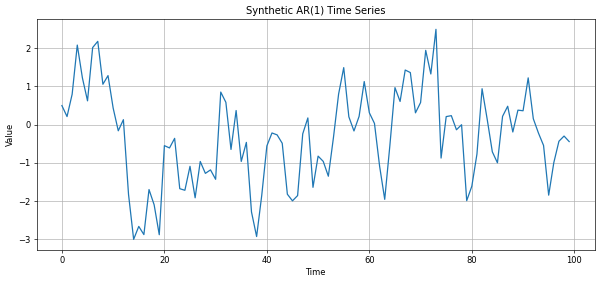


Sample Mean of the time series: -0.3358

Empirical Autocovariance for different lags:
Lag 0: 1.5086
Lag 1: 1.0199
Lag 2: 0.6876
Lag 3: 0.4886
Lag 4: 0.3730
Lag 5: 0.3691
Lag 6: 0.1882
Lag 7: 0.0523
Lag 8: -0.0788
Lag 9: -0.0717
Lag 10: -0.0782
Lag 11: 0.0168
Lag 12: -0.0533
Lag 13: -0.0847
Lag 14: 0.0135
Lag 15: -0.0801
Lag 16: -0.0390
Lag 17: -0.0567
Lag 18: -0.0094
Lag 19: -0.0030
Lag 20: -0.0668


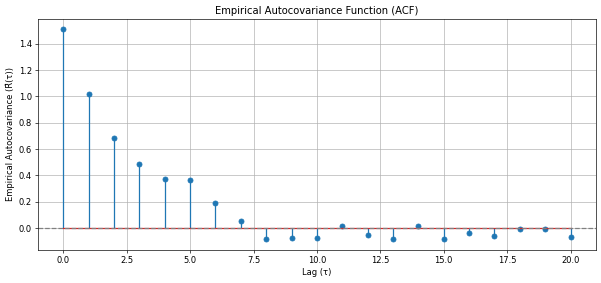

In [ ]:
# 1. Generate a synthetic time series (e.g., an AR(1) process)
# X_t = 0.7 * X_{t-1} + W_t
np.random.seed(42) # for reproducibility
N = 100 # Number of observations
alpha = 0.7
sigma_w = 1.0

white_noise = np.random.normal(0, sigma_w, N)
time_series = np.zeros(N)
time_series[0] = white_noise[0] # Initial value

for t in range(1, N):
    time_series[t] = alpha * time_series[t-1] + white_noise[t]

# Plot the generated time series
plt.figure(figsize=(12, 5), dpi=60)
plt.plot(time_series)
plt.title('Synthetic AR(1) Time Series')
plt.xlabel('Time') ; plt.ylabel('Value') ; plt.grid(True) ; plt.show()

# 2. Define a function to compute empirical autocovariance
def empirical_autocovariance(series, lag):
    n = len(series)
    mean = np.mean(series)
    if lag < 0 or lag >= n:
        return 0

    # Summation from t=0 to N-tau-1
    sum_products = np.sum((series[:n-lag] - mean) * (series[lag:] - mean))

    # Divide by N as per the definition used above
    return sum_products / n

# 3. Compute and display empirical autocovariances for several lags
max_lag = 20 # Up to which lag to compute
lags = np.arange(max_lag + 1)

empirical_acf_values = [empirical_autocovariance(time_series, lag) for lag in lags]

for i, lag in enumerate(lags):
    print(f"Lag {lag}: {empirical_acf_values[i]:.4f}")

# Plot the empirical autocovariance function
plt.figure(figsize=(12, 5), dpi=60)
plt.stem(lags, empirical_acf_values)
plt.title('Empirical Autocovariance Function (ACF)')
plt.xlabel('Lag (τ)') ; plt.ylabel('Empirical Autocovariance (R̂(τ))')
plt.grid(True) ; plt.axhline(y=0, color='gray', linestyle='--') ; plt.show()


##### Empirical Autocovariance and Identifying the Order of an AR Model by PACF

**Fitting AR Model to CPI Data**

The CPI (consumer price index) is released monthly by the Bureau of Labor Statistics, and is given in CPI.csv. There is more than a decade of data in CPI.csv. Perform all of model fitting on the months prior to September 2013, and use the remaining months for evaluation.

Additional References:
CPI is a measure of the average change over time in the prices paid by urban consumers for a market basket of consumer goods and services. To read more, visit [https://www.bls.gov/cpi](https://www.bls.gov/cpi).


**Detrend CPI**

We detrend this data into $CPI_t = T_t + R_t$ where $T_t$ is the trend and $R_t$ are the residuals.

1.  Fit a linear trend to the training data.
2.  Subtract the linear trend from the data to get the residuals $R_t$. Visualize $R_t$.

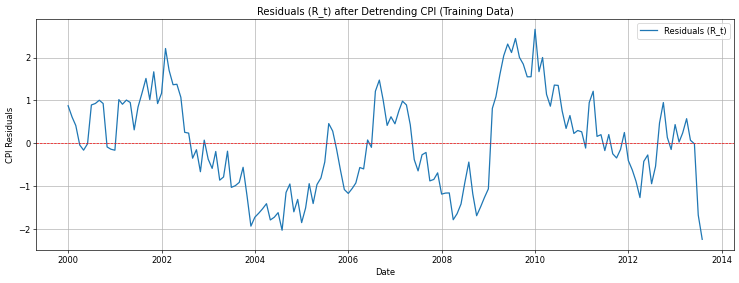

,CPI,Trend,Residuals
Date,,,
2000-01-01,169.292315,168.415913,0.876402
2000-02-01,169.447846,168.834638,0.613207
2000-03-01,169.642342,169.226349,0.415993
2000-04-01,169.607057,169.645075,-0.038018
2000-05-01,169.892268,170.050293,-0.158025


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

# Check if CPI.csv exists, if not, create a dummy file for demonstration
if not os.path.exists('CPI.csv'):
    print("CPI.csv not found. Creating a dummy file for demonstration purposes.")
    dates = pd.date_range(start='2000-01-01', periods=165, freq='MS') # Up to Sep 2013 + some months
    cpi_values = np.linspace(170, 230, len(dates)) + np.random.normal(0, 1, len(dates)).cumsum() * 0.5
    dummy_cpi_df = pd.DataFrame({'Date': dates, 'CPI': cpi_values})
    dummy_cpi_df.to_csv('CPI.csv', index=False)

# Load the CPI data
cpi_df = pd.read_csv('CPI.csv')

# Convert 'Date' to datetime objects and set as index
cpi_df['Date'] = pd.to_datetime(cpi_df['Date'])
cpi_df = cpi_df.set_index('Date')

# Filter data for training (months prior to September 2013)
training_data = cpi_df[cpi_df.index < '2013-09-01'].copy() # Use .copy() to avoid SettingWithCopyWarning

# Prepare data for linear regression
# We need a numerical representation of time. Using `ordinal` is a common approach.
X_train = np.array([x.toordinal() for x in training_data.index]).reshape(-1, 1)
y_train = training_data['CPI'].values

# Fit a linear trend to the training data
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Get the trend component and calculate residuals (R_t)
training_data.loc[:, 'Trend'] = linear_model.predict(X_train)
training_data.loc[:, 'Residuals'] = training_data['CPI'] - training_data['Trend']

# Visualize the residuals R_t
plt.figure(figsize=(15, 5), dpi=60)
plt.plot(training_data.index, training_data['Residuals'], label='Residuals (R_t)')
plt.title('Residuals (R_t) after Detrending CPI (Training Data)')
plt.xlabel('Date') ; plt.ylabel('CPI Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.grid(True) ; plt.legend() ; plt.show()

display(training_data.head())

##### **AR Model: Determine the Lag**

As there is no other clear trend or seasonality present in this residual, we directly proceed to fitting a model to the data. Select an AR Model on the residual $R_t$.
Determine the order of the AR model by examining the auto-correlation and/or partial auto-correlation functions of the residuals. Start with a single AR term and add other terms as necessary.

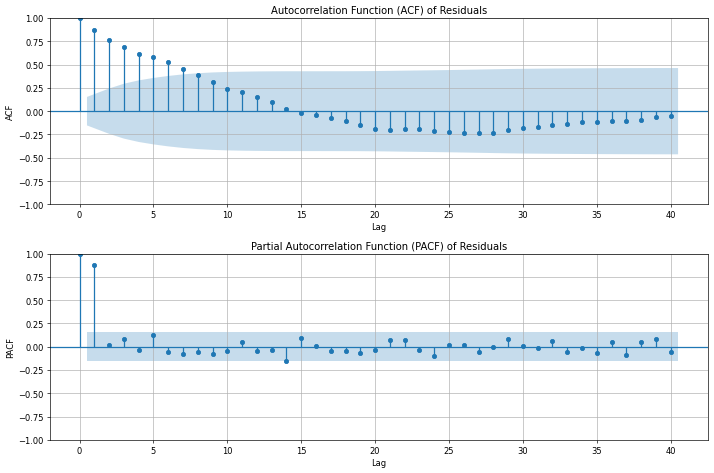

Interpretation:
- The ACF measures the correlation between a time series and a lagged version of itself. For an AR(p) model, the ACF typically decays exponentially or sinusoidally.
- The PACF measures the correlation between a time series and a lagged version of itself after removing the effects of intermediate lags. For an AR(p) model, the PACF typically cuts off abruptly after lag p.
Based on these plots, we can determine the appropriate order 'p' for our AR model. Look for where the PACF drops significantly or cuts off.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Get the residuals from the training data
residuals = training_data['Residuals']
# Plot ACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), dpi=60)
plot_acf(residuals, lags=40, ax=ax1, title='Autocorrelation Function (ACF) of Residuals')
ax1.set_xlabel('Lag') ; ax1.set_ylabel('ACF') ; ax1.grid(True)
# Plot PACF
plot_pacf(residuals, lags=40, ax=ax2, title='Partial Autocorrelation Function (PACF) of Residuals')
ax2.set_xlabel('Lag') ; ax2.set_ylabel('PACF') ; ax2.grid(True)
plt.tight_layout() ; plt.show()

print("Interpretation:")
print("- The ACF measures the correlation between a time series and a lagged version of itself. For an AR(p) model, the ACF typically decays exponentially or sinusoidally.")
print("- The PACF measures the correlation between a time series and a lagged version of itself after removing the effects of intermediate lags. For an AR(p) model, the PACF typically cuts off abruptly after lag p.")
print("Based on these plots, we can determine the appropriate order 'p' for our AR model. Look for where the PACF drops significantly or cuts off.")

##### **AR Model: Find the Parameters**

Using the lag from the previous problem, fit an AR(p) model to the residuals in the training period. Recall the AR(p) model $X_t = \alpha_1 X_{t-1} + \dots + \alpha_p X_{t-p} + \epsilon_t$

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

# Assuming an AR(1) model based on PACF plot, where lag 1 was most significant.
# For a more robust approach, one might also test AR(2) or consider information criteria like AIC/BIC.
p = 1

# Get the residuals from the training data (from previous step)
residuals = training_data['Residuals']

# Fit the AR(p) model to the residuals
# The 'lags' argument specifies the order of the AR model
model = AutoReg(residuals, lags=p)
model_fit = model.fit()

# Print the model summary to show estimated parameters
print(f"\nAR({p}) Model Summary for Residuals:")
print(model_fit.summary())


AR(1) Model Summary for Residuals:
                            AutoReg Model Results                             
Dep. Variable:              Residuals   No. Observations:                  164
Model:                     AutoReg(1)   Log Likelihood                -119.470
Method:               Conditional MLE   S.D. of innovations              0.504
Date:                Tue, 17 Mar 2026   AIC                            244.939
Time:                        10:52:22   BIC                            254.221
Sample:                    02-01-2000   HQIC                           248.707
                         - 08-01-2013                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.0177      0.039     -0.448      0.654      -0.095       0.060
Residuals.L1     0.8971      0.037     24.557      0.000       0.826       0.969
        

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
